<a href="https://colab.research.google.com/github/taniahuertas/TelcomX_2/blob/master/Telecom_X_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.ensemble import RandomForestClassifier

# Carga de Datos

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/taniahuertas/TelcomX_2/refs/heads/master/df_final_1.csv', index_col='Unnamed: 0')
df.head().T

,0,1,2,3,4
Customer_ID,0002-ORFBO,0003-MKNFE,0004-TLHLJ,0011-IGKFF,0013-EXCHZ
Churn,0,0,1,1,1
Gender,Female,Male,Male,Male,Female
Senior_Citizen,No Senior,No Senior,No Senior,Senior,Senior
Partner,1,0,0,1,1
Dependents,1,0,0,0,0
Tenure,9,9,4,13,3
Phone_Service,1,1,1,1,1
Multiple_Lines,0,1,0,0,0
Internet_Service,DSL,DSL,Fiber optic,Fiber optic,Fiber optic


# Preparación de Datos

## Eliminación de variables irrelevantes
Se elimina columna de ID

In [3]:
df.columns

Index(['Customer_ID', 'Churn', 'Gender', 'Senior_Citizen', 'Partner',
       'Dependents', 'Tenure', 'Phone_Service', 'Multiple_Lines',
       'Internet_Service', 'Online_Security', 'Online_Backup',
       'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies',
       'Contract', 'Paperless_Billing', 'Payment_Method', 'Charges_Monthly',
       'Charges_Total', 'Charges_Daily', 'Gasto_Rango', 'Tenure_Rango',
       'Daily_Range'],
      dtype='object')

In [4]:
df_2 = df[['Churn', 'Gender', 'Senior_Citizen', 'Partner',
       'Dependents', 'Tenure', 'Phone_Service', 'Multiple_Lines',
       'Internet_Service', 'Online_Security', 'Online_Backup',
       'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies',
       'Contract', 'Paperless_Billing', 'Payment_Method', 'Charges_Monthly',
       'Charges_Total', 'Charges_Daily', 'Gasto_Rango', 'Tenure_Rango',
       'Daily_Range']]
df_2.head()

,Churn,Gender,Senior_Citizen,Partner,Dependents,Tenure,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Charges_Monthly,Charges_Total,Charges_Daily,Gasto_Rango,Tenure_Rango,Daily_Range
0,0,Female,No Senior,1,1,9,1,0,DSL,0,...,0,One year,1,Mailed check,65.6,593.30,2.186667,Bajo Gasto,0-12 Meses,Costo/Día Medio
1,0,Male,No Senior,0,0,9,1,1,DSL,0,...,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667,Bajo Gasto,0-12 Meses,Costo/Día Medio
2,1,Male,No Senior,0,0,4,1,0,Fiber optic,0,...,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333,Bajo Gasto,0-12 Meses,Costo/Día Medio
3,1,Male,Senior,1,0,13,1,0,Fiber optic,0,...,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,Gasto Medio,0-12 Meses,Alto Costo/Día
4,1,Female,Senior,1,0,3,1,0,Fiber optic,0,...,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667,Bajo Gasto,0-12 Meses,Costo/Día Medio


In [5]:
cols_int = df_2.select_dtypes(include='int64').columns
df_2[cols_int] = df_2[cols_int].astype('object')
df_2.head()

/tmp/ipykernel_45850/3946438527.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2[cols_int] = df_2[cols_int].astype('object')


,Churn,Gender,Senior_Citizen,Partner,Dependents,Tenure,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Charges_Monthly,Charges_Total,Charges_Daily,Gasto_Rango,Tenure_Rango,Daily_Range
0,0,Female,No Senior,1,1,9,1,0,DSL,0,...,0,One year,1,Mailed check,65.6,593.30,2.186667,Bajo Gasto,0-12 Meses,Costo/Día Medio
1,0,Male,No Senior,0,0,9,1,1,DSL,0,...,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667,Bajo Gasto,0-12 Meses,Costo/Día Medio
2,1,Male,No Senior,0,0,4,1,0,Fiber optic,0,...,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333,Bajo Gasto,0-12 Meses,Costo/Día Medio
3,1,Male,Senior,1,0,13,1,0,Fiber optic,0,...,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,Gasto Medio,0-12 Meses,Alto Costo/Día
4,1,Female,Senior,1,0,3,1,0,Fiber optic,0,...,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667,Bajo Gasto,0-12 Meses,Costo/Día Medio


In [6]:
df_2['Tenure'] = df_2['Tenure'].astype('int')
df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7267 entries, 0 to 7266
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Churn              7267 non-null   object 
 1   Gender             7267 non-null   object 
 2   Senior_Citizen     7267 non-null   object 
 3   Partner            7267 non-null   object 
 4   Dependents         7267 non-null   object 
 5   Tenure             7267 non-null   int64  
 6   Phone_Service      7267 non-null   object 
 7   Multiple_Lines     7267 non-null   object 
 8   Internet_Service   7267 non-null   object 
 9   Online_Security    7267 non-null   object 
 10  Online_Backup      7267 non-null   object 
 11  Device_Protection  7267 non-null   object 
 12  Tech_Support       7267 non-null   object 
 13  Streaming_TV       7267 non-null   object 
 14  Streaming_Movies   7267 non-null   object 
 15  Contract           7267 non-null   object 
 16  Paperless_Billing  7267 non-n

/tmp/ipykernel_45850/1980849304.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2['Tenure'] = df_2['Tenure'].astype('int')


In [8]:
# Separar variables predictoras de variable objetivo (churn)
# Se excluyen gasto_rango, tenure_rango y daily_rango porque se tienen en cuenta en las variables numérica

cat_var = ['Gender', 'Senior_Citizen', 'Partner', 'Dependents',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method']
num_var = ['Charges_Daily','Charges_Total','Charges_Monthly','Tenure']

X = df_2[cat_var + num_var]
y = df_2['Churn'].astype('int')

print(X.shape)
print(y.shape)

(7267, 20)
(7267,)


In [9]:
# Como buena práctica se debe dividir la data en entrenamiento, validación y test antes de continuar con la preparación de la data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42)

print("Train: ", X_train.shape,y_train.shape)
print("Validation: ",X_val.shape,y_val.shape)
print("Test: ",X_test.shape,y_test.shape)


Train:  (5086, 20) (5086,)
Validation:  (727, 20) (727,)
Test:  (1454, 20) (1454,)


## Encoding

In [10]:
# Codificación de las variables categóricas por el método de one-hot

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_var)
    ],
    remainder='passthrough'
)

X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test)

In [11]:
X_train_enc

array([[1.00000e+00, 0.00000e+00, 1.00000e+00, ..., 2.88050e+02,
        5.08000e+01, 6.00000e+00],
       [0.00000e+00, 1.00000e+00, 1.00000e+00, ..., 2.46055e+03,
        4.52000e+01, 5.40000e+01],
       [1.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.23800e+02,
        7.01500e+01, 2.00000e+00],
       ...,
       [1.00000e+00, 0.00000e+00, 1.00000e+00, ..., 2.27490e+03,
        6.26500e+01, 3.40000e+01],
       [1.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.63550e+02,
        3.42500e+01, 5.00000e+00],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 4.28480e+03,
        1.05650e+02, 3.90000e+01]])

## Verificación de la Proporción de Cancelación (Churn)

In [12]:
y_train.value_counts(normalize=True)

,proportion
Churn,
0,0.739874
1,0.260126


In [13]:
y_val.value_counts(normalize=True)

,proportion
Churn,
0,0.76066
1,0.23934


In [14]:
y_test.value_counts(normalize=True)

,proportion
Churn,
0,0.744154
1,0.255846


Hay un desbalance entre las categorías de churn, hay sobre-representación de los "no churners" en una proporción aproximada 3:1

## Balanceo de Clases (opcional)

In [15]:
# Se va a aplicar de sobre muestreo de la variable minoritaria con el método SMOTE
# Con esto se balancean las clases, de tal manera que quedan 50% cada clase

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_enc, y_train)

y_train_sm.value_counts(normalize=True)

,proportion
Churn,
1,0.5
0,0.5


## Análisis de Correlación

In [18]:
# Convertir X_train_sm y y_train_sm a dataframe

X_train_sm_df = pd.DataFrame(
    X_train_sm,
    columns=preprocessor.get_feature_names_out()
)

y_train_sm_df = pd.DataFrame(
    y_train_sm,
    columns=['Churn']
)

X_train_sm_df.head()

,cat__Gender_Female,cat__Gender_Male,cat__Senior_Citizen_No Senior,cat__Senior_Citizen_Senior,cat__Partner_0,cat__Partner_1,cat__Dependents_0,cat__Dependents_1,cat__Phone_Service_0,cat__Phone_Service_1,...,cat__Paperless_Billing_0,cat__Paperless_Billing_1,cat__Payment_Method_Bank transfer (automatic),cat__Payment_Method_Credit card (automatic),cat__Payment_Method_Electronic check,cat__Payment_Method_Mailed check,remainder__Charges_Daily,remainder__Charges_Total,remainder__Charges_Monthly,remainder__Tenure
0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.693333,288.05,50.80,6.0
1,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.506667,2460.55,45.20,54.0
2,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,2.338333,123.80,70.15,2.0
3,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,2.148333,4528.00,64.45,72.0
4,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.815000,993.15,24.45,43.0


<Axes: >

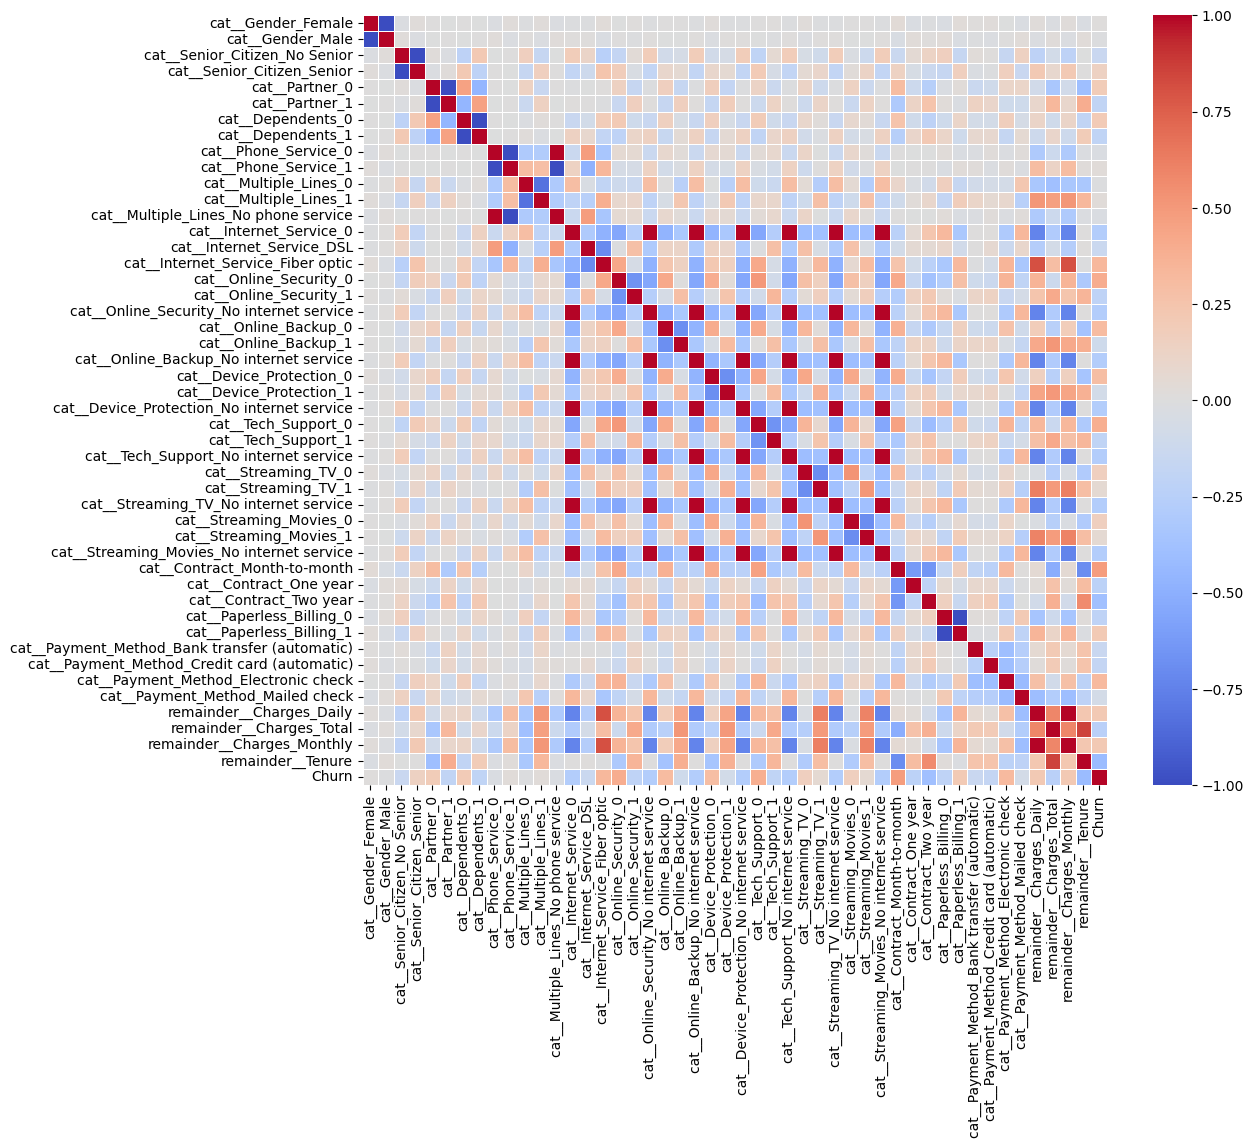

In [22]:
#Matriz de correlación contra churn

corr_matrix = pd.concat([X_train_sm_df, y_train_sm_df], axis=1).corr()

#Visualizar con seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Selección de Variables

In [37]:
# Ordernar corr_matrix por su correlación contra churn

corr_matrix.abs().sort_values(by='Churn', ascending=False)['Churn'].head(30)

,Churn
Churn,1.000000
cat__Contract_Month-to-month,0.478451
remainder__Tenure,0.417183
cat__Online_Security_0,0.393388
cat__Tech_Support_0,0.389486
cat__Contract_Two year,0.383198
cat__Internet_Service_Fiber optic,0.335764
cat__Payment_Method_Electronic check,0.315898
cat__Online_Backup_0,0.310383
cat__Device_Protection_0,0.292252


In [38]:
corr_matrix.abs().sort_values(by='Churn', ascending=False)['Churn'].head(30).index

Index(['Churn', 'cat__Contract_Month-to-month', 'remainder__Tenure',
       'cat__Online_Security_0', 'cat__Tech_Support_0',
       'cat__Contract_Two year', 'cat__Internet_Service_Fiber optic',
       'cat__Payment_Method_Electronic check', 'cat__Online_Backup_0',
       'cat__Device_Protection_0', 'cat__Online_Security_No internet service',
       'cat__Internet_Service_0', 'cat__Tech_Support_No internet service',
       'cat__Streaming_Movies_No internet service',
       'cat__Streaming_TV_No internet service',
       'cat__Online_Backup_No internet service',
       'cat__Device_Protection_No internet service',
       'remainder__Charges_Total', 'cat__Contract_One year',
       'remainder__Charges_Daily', 'remainder__Charges_Monthly',
       'cat__Online_Security_1', 'cat__Paperless_Billing_0',
       'cat__Paperless_Billing_1', 'cat__Tech_Support_1', 'cat__Dependents_1',
       'cat__Dependents_0', 'cat__Partner_1', 'cat__Partner_0',
       'cat__Payment_Method_Credit card (automat

## Análisis Dirigido

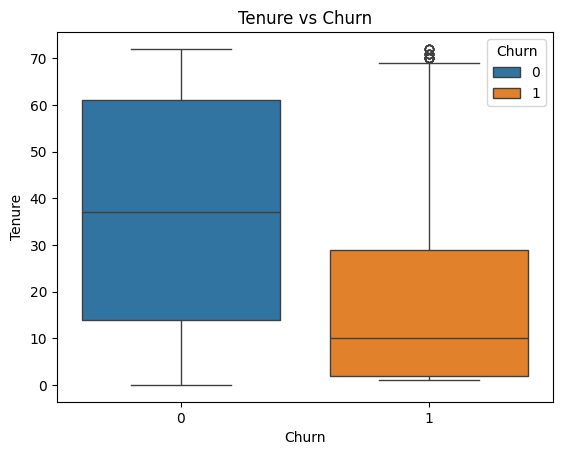

In [34]:
sns.boxplot(x='Churn', y='Tenure', data=df_2, hue='Churn')
plt.title("Tenure vs Churn")
plt.show()

Los clientes nuevos tienden a hacer más churn que aquellos clientes que superan los 30 meses

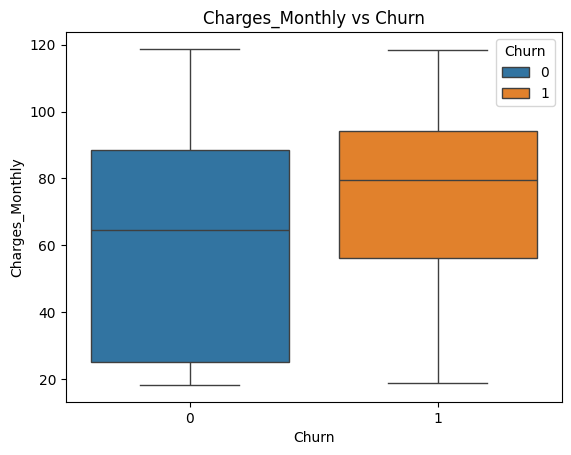

In [35]:
sns.boxplot(x='Churn', y='Charges_Monthly', data=df_2, hue='Churn')
plt.title("Charges_Monthly vs Churn")
plt.show()

Los clientes que hacen churn tienden a tener contratos con fees mensuales más bajos.

# Modelos Predictivos

## Creación Modelos

### Random Forest

In [ ]:
X_train_sm_df = X_train_sm_df[['cat__Contract_Month-to-month', 'remainder__Tenure',
       'cat__Online_Security_0', 'cat__Tech_Support_0',
       'cat__Contract_Two year', 'cat__Internet_Service_Fiber optic',
       'cat__Payment_Method_Electronic check', 'cat__Online_Backup_0',
       'cat__Device_Protection_0', 'cat__Online_Security_No internet service',
       'cat__Internet_Service_0', 'cat__Tech_Support_No internet service',
       'cat__Streaming_Movies_No internet service',
       'cat__Streaming_TV_No internet service',
       'cat__Online_Backup_No internet service',
       'cat__Device_Protection_No internet service',
       'remainder__Charges_Total', 'cat__Contract_One year', 'remainder__Charges_Monthly',
       'cat__Online_Security_1', 'cat__Paperless_Billing_0',
       'cat__Paperless_Billing_1', 'cat__Tech_Support_1', 'cat__Dependents_1',
       'cat__Dependents_0', 'cat__Partner_1', 'cat__Partner_0',
       'cat__Payment_Method_Credit card (automatic)']]

In [40]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_sm_df, y_train_sm_df)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=42)

In [41]:
y_train_pred = rf.predict(X_train_sm_df)

#Evaluar pred vs el real
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train_sm_df, y_train_pred))
print(confusion_matrix(y_train_sm_df, y_train_pred))
print(classification_report(y_train_sm_df, y_train_pred))

0.9932234918947648
[[3731   32]
 [  19 3744]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3763
           1       0.99      0.99      0.99      3763

    accuracy                           0.99      7526
   macro avg       0.99      0.99      0.99      7526
weighted avg       0.99      0.99      0.99      7526



In [42]:
# Evaluación del modelo para ajustar hiperparametros

y_pred_val = rf.predict(X_val_enc)
print(accuracy_score(y_val, y_pred_val))
print(confusion_matrix(y_val, y_pred_val))
print(classification_report(y_val, y_pred_val))


0.7771664374140302
[[483  70]
 [ 92  82]]
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       553
           1       0.54      0.47      0.50       174

    accuracy                           0.78       727
   macro avg       0.69      0.67      0.68       727
weighted avg       0.77      0.78      0.77       727



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [44]:
# Ooptimización de los hiperparametros max_depth y min_samples_leaf. Se prueban 18 modelos distintos.

# 1. Definimos el espacio de búsqueda (Hyperparameter Space)
param_grid = {
    'max_depth': [5, 10, 15],              # Limita la profundidad para reducir el 99% de train
    'min_samples_leaf': [10, 20, 50],      # Obliga a las hojas a ser más generales
    'max_features': ['sqrt', 'log2'],      # Aumenta la aleatoriedad
    'class_weight': ['balanced']           # Crucial para mejorar ese 0.47 de recall
}

# 2. Creamos el objeto GridSearchCV
# Usamos 'f1' o 'recall' como scoring para priorizar la clase 1
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,                                  # Validación cruzada de 5 pliegues
    scoring='f1',                          # Buscamos el mejor equilibrio entre precision y recall
    n_jobs=-1                              # Usa todos los procesadores disponibles
)

# 3. Entrenamos con los datos de entrenamiento
grid_search.fit(X_train_sm_df, y_train_sm_df)

# 4. Resultados
print(f"Mejores parámetros: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mejores parámetros: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 10}


In [45]:
y_train_pred = best_rf.predict(X_train_sm_df)

print(accuracy_score(y_train_sm_df, y_train_pred))
print(confusion_matrix(y_train_sm_df, y_train_pred))
print(classification_report(y_train_sm_df, y_train_pred))

0.836433696518735
[[3022  741]
 [ 490 3273]]
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      3763
           1       0.82      0.87      0.84      3763

    accuracy                           0.84      7526
   macro avg       0.84      0.84      0.84      7526
weighted avg       0.84      0.84      0.84      7526



In [46]:
y_pred_val = best_rf.predict(X_val_enc)

print(accuracy_score(y_val, y_pred_val))
print(confusion_matrix(y_val, y_pred_val))
print(classification_report(y_val, y_pred_val))

0.7757909215955984
[[444 109]
 [ 54 120]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84       553
           1       0.52      0.69      0.60       174

    accuracy                           0.78       727
   macro avg       0.71      0.75      0.72       727
weighted avg       0.80      0.78      0.79       727



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Optimizando los hiperparametros se ve una mejora significativa en el modelo de arboles aleatorios.

1. Reducción drástica de la brecha (Gap)
Antes se tenía un 99.3% en entrenamiento y un 77.7% en validación. Una diferencia de más de 21 puntos, lo que indicaba que el modelo simplemente había memorizado los datos de entrenamiento.  Ahora se tiene un 83.6% en entrenamiento y un 77.6% en validación. La diferencia ahora es de solo 6 puntos aproximadamente. Esto indica un modelo mucho más robusto y capaz de generalizar a datos que no ha visto nunca.

2. Mejora crítica en la Clase 1 (Churn)
Antes se tenía un recall de 0.47 y ahora pasó a 0.69 (+22 p.p de captura de churners). El recall pasó de 0.50 a 0.60 mostrando que hay un modelo más equilibrado.

3. **Falsos Negativos** (Clientes que se van pero no detectas): Bajaron de 92 a 54. Se ha reducido el error más costoso para la empresa casi a la mitad. **Falsos Positivos** (Clientes que se quedan pero predices que se van): Subieron de 70 a 109. Este es el "precio" de hacer el modelo más sensible, pero suele ser preferible enviar una promoción de retención a alguien que no la necesitaba que perder a un cliente real.

### XGBoost

In [51]:
xg = xgb.XGBClassifier(random_state=42)
xg.fit(X_train_sm_df, y_train_sm_df)


#Evaluación modelo
y_train_pred_xg = xg.predict(X_train_sm_df)

print(accuracy_score(y_train_sm_df, y_train_pred_xg))
print(confusion_matrix(y_train_sm_df, y_train_pred_xg))
print(classification_report(y_train_sm_df, y_train_pred_xg))

0.9532288068030826
[[3608  155]
 [ 197 3566]]
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      3763
           1       0.96      0.95      0.95      3763

    accuracy                           0.95      7526
   macro avg       0.95      0.95      0.95      7526
weighted avg       0.95      0.95      0.95      7526



In [52]:
# Evaluación de modelo con data de validación
y_val_pred_xg = xg.predict(X_val_enc)

print(accuracy_score(y_val, y_val_pred_xg))
print(confusion_matrix(y_val, y_val_pred_xg))
print(classification_report(y_val, y_val_pred_xg))

0.7661623108665749
[[472  81]
 [ 89  85]]
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       553
           1       0.51      0.49      0.50       174

    accuracy                           0.77       727
   macro avg       0.68      0.67      0.67       727
weighted avg       0.76      0.77      0.76       727



In [59]:
# Se entrenan 27 modelos

# 1. Definimos el espacio de búsqueda
param_grid_xg = {
    'learning_rate': [0.01, 0.05, 0.1],    # Tasas más bajas ayudan a no sobreajustar rápido
    'max_depth': [3, 5, 7],               # XGBoost suele funcionar mejor con árboles poco profundos
    'subsample': [0.7, 0.8, 0.9],        # Porcentaje de filas usadas por cada árbol
}

# 2. Creamos el objeto
grid_xg = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=param_grid_xg,
    cv=5,
    scoring='f1',                          # Optimizamos para mejorar el recall sin perder mucha precisión
    n_jobs=-1
)

# 3. Entrenamiento
grid_xg.fit(X_train_sm_df, y_train_sm_df)

print(f"Mejores parámetros XGB: {grid_xg.best_params_}")
best_xg = grid_xg.best_estimator_

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:03:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mejores parámetros XGB: {'learning_rate': 0.01, 'max_depth': 7, 'subsample': 0.9}


In [60]:
y_train_pred_xg = best_xg.predict(X_train_sm_df)


#Evaluación modelo
print(accuracy_score(y_train_pred_xg, y_train_pred))
print(confusion_matrix(y_train_pred_xg, y_train_pred))
print(classification_report(y_train_pred_xg, y_train_pred))

0.9212064841881478
[[3350  431]
 [ 162 3583]]
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      3781
           1       0.89      0.96      0.92      3745

    accuracy                           0.92      7526
   macro avg       0.92      0.92      0.92      7526
weighted avg       0.92      0.92      0.92      7526



In [62]:
# Evaluación de modelo con data de validación
y_pred_val_xg = best_xg.predict(X_val_enc)

print(accuracy_score(y_val, y_pred_val_xg))
print(confusion_matrix(y_val, y_pred_val_xg))
print(classification_report(y_val, y_pred_val_xg))

0.7936726272352133
[[467  86]
 [ 64 110]]
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       553
           1       0.56      0.63      0.59       174

    accuracy                           0.79       727
   macro avg       0.72      0.74      0.73       727
weighted avg       0.80      0.79      0.80       727



A pesar que con la optimización de hiperparametros en el XGBoost se mejora el rendimiento del modelo comparando contra el modelo inicial, sigue presentandose overfitting, especialmente en el recall donde es más importante para el negocio identificar proactivamente clientes que van a desertar.

# Análisis de la Importancia de las Variables

## Random Forest

                                Variable  Importancia
34          cat__Contract_Month-to-month     0.143153
16                cat__Online_Security_0     0.113347
25                   cat__Tech_Support_0     0.100911
41  cat__Payment_Method_Electronic check     0.065158
19                  cat__Online_Backup_0     0.061323
46                     remainder__Tenure     0.051155
15     cat__Internet_Service_Fiber optic     0.042561
22              cat__Device_Protection_0     0.039901
36                cat__Contract_Two year     0.039673
38              cat__Paperless_Billing_1     0.035042


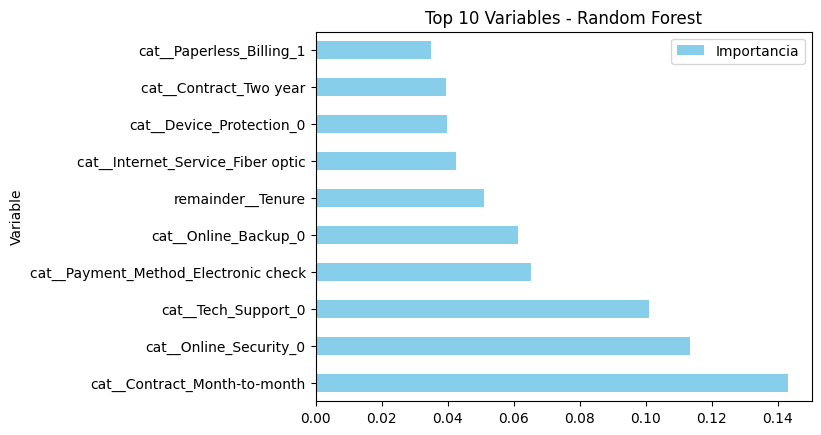

In [63]:
# Importancia características para Random Forest

# Extraer importancias del mejor modelo de tu GridSearch
importancias_rf = best_rf.feature_importances_

# Crear un DataFrame para visualizarlas mejor
feature_df_rf = pd.DataFrame({
    'Variable': X_train_sm_df.columns,
    'Importancia': importancias_rf
}).sort_values(by='Importancia', ascending=False)

# Mostrar el Top 10
print(feature_df_rf.head(10))

# Graficar
feature_df_rf.head(10).plot(kind='barh', x='Variable', y='Importancia', color='skyblue')
plt.title("Top 10 Variables - Random Forest")
plt.show()

## XGBoost

                                Variable  Importancia
34          cat__Contract_Month-to-month     0.314987
26                   cat__Tech_Support_1     0.111202
38              cat__Paperless_Billing_1     0.075448
16                cat__Online_Security_0     0.049784
25                   cat__Tech_Support_0     0.049086
5                         cat__Partner_1     0.047819
15     cat__Internet_Service_Fiber optic     0.035962
41  cat__Payment_Method_Electronic check     0.035938
17                cat__Online_Security_1     0.035768
14             cat__Internet_Service_DSL     0.021390


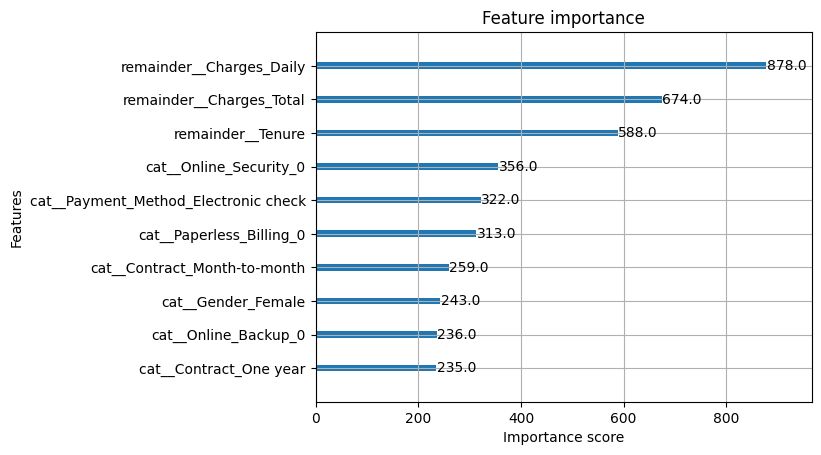

In [65]:
# Extraer importancias del mejor XGBoost
importancias_xg = best_xg.feature_importances_

feature_df_xg = pd.DataFrame({
    'Variable': X_train_sm_df.columns,
    'Importancia': importancias_xg
}).sort_values(by='Importancia', ascending=False)

# Mostrar el Top 10
print(feature_df_xg.head(10))

# Graficar usando la función nativa de XGBoost (es más rápida)
plot_importance(best_xg, max_num_features=10)
plt.show()

# Conclusiones



*   Los principales objetivos fueron identificar los factores que más influyen en el churn y desarrollar modelos capaces de predecir la probabilidad de que un cliente abandone el servicio.
*   El análisis inicial de los datos reveló una dataset de 7267 clientes, donde la variable objetivo 'Churn' presentaba un desbalance significativo, con aproximadamente un 74% de clientes no-churners y un 26% de churners. Para abordar este desbalance y preparar el conjunto de entrenamiento para los modelos, se aplicó la técnica SMOTE, logrando una distribución equitativa de las clases (50/50).

* Factores Clave de Churn: La exploración de correlaciones y el
análisis dirigido, respaldado por la importancia de las características de ambos modelos (Random Forest y XGBoost), destacaron varios factores clave asociados con la cancelación:

1.  Contrato: Los clientes con contratos mes a mes ('cat__Contract_Month-to-month') mostraron la correlación positiva más fuerte con el churn. En contraste, los contratos de dos años ('cat__Contract_Two year') tuvieron una fuerte correlación negativa, indicando una mayor lealtad.

2. Antigüedad (Tenure): Los clientes con menor antigüedad ('remainder__Tenure') son significativamente más propensos a la cancelación. El boxplot de 'Tenure vs Churn' confirmó que los clientes que abandonan tienen una antigüedad promedio mucho más baja.

3. Servicios de Seguridad y Soporte: La ausencia de servicios como 'Online Security' ('cat__Online_Security_0') y 'Tech Support' ('cat__Tech_Support_0') mostró una alta correlación con el churn. Esto sugiere que estos servicios actúan como retenedores clave.

4. Servicio de Internet: El servicio de internet de fibra óptica ('cat__Internet_Service_Fiber optic') se asoció con una mayor propensión al churn, posiblemente debido a expectativas no cumplidas o a una mayor competencia en este segmento.

5. Cargos Mensuales (Charges_Monthly): Contrario a una posible intuición de que cargos bajos podrían indicar menor valor, el boxplot de 'Charges_Monthly vs Churn' y la correlación positiva indican que los clientes que churn tienden a tener cargos mensuales más altos.

6. Método de Pago: El método de pago 'Electronic check' ('cat__Payment_Method_Electronic check') también presentó una correlación positiva con el churn.

* Rendimiento de los Modelos Predictivos: Se entrenaron y optimizaron dos modelos principales: Random Forest y XGBoost. Tras la optimización de hiperparámetros, ambos modelos mostraron mejoras significativas en su capacidad para predecir el churn:

* Random Forest (optimizado): Pasó de un recall de 0.47 a 0.69 para la clase 'Churn' en el conjunto de validación, con un F1-score de 0.60 y una precisión de 0.52. La diferencia entre el rendimiento en entrenamiento y validación se redujo drásticamente, indicando un modelo más robusto y menos sobreajustado.

* XGBoost (optimizado): Este modelo también mejoró, alcanzando un recall de 0.63 para la clase 'Churn' en el conjunto de validación, con un F1-score de 0.59 y una precisión de 0.56. Aunque ligeramente inferior en recall a Random Forest, su F1-score es comparable.

* **Implicaciones de Negocio y Estrategias de Retención:** Los resultados sugieren que los clientes que están en riesgo de churn son aquellos con contratos de mes a mes, de baja antigüedad, que no contratan servicios de seguridad o soporte técnico, que usan fibra óptica y que pagan con cheque electrónico. Además, los clientes con tarifas mensuales más altas también presentan un riesgo elevado.

